## Netflix Project

#### by Wolfrank Guzman <br>

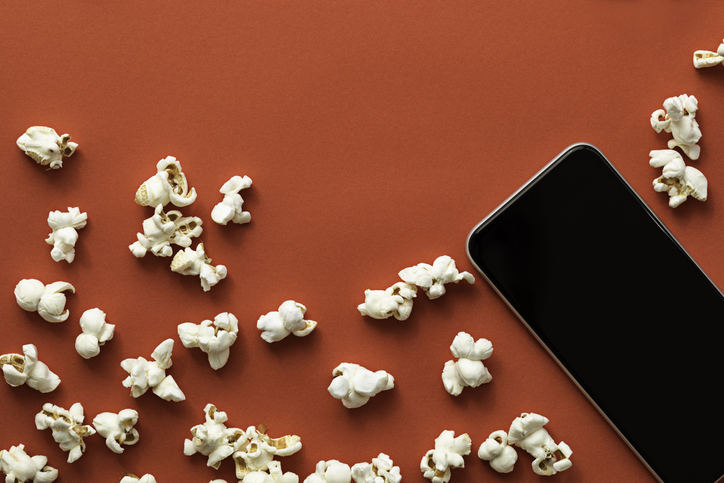

**Netflix**! What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies.

Given the large number of movies and series available on the platform, it is a perfect opportunity to flex your exploratory data analysis skills and dive into the entertainment industry. Our friend has also been brushing up on their Python skills and has taken a first crack at a CSV file containing Netflix data. They believe that the average duration of movies has been declining. Using your friends initial research, you'll delve into the Netflix data to see if you can determine whether movie lengths are actually getting shorter and explain some of the contributing factors, if any.

You have been supplied with the dataset `netflix_data.csv` , along with the following table detailing the column names and descriptions:

## The data
### **netflix_data.csv**
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

### Import Modules and CSV, convert CSV to Pandas Dataframe 

In [18]:
# Importing pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create dataframe off csv file 
netflix_df = pd.read_csv("netflix_data.csv")

# Print the first five rows of the dataframe
netflix_df.head()



,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4,In a future where the elite inhabit an island ...,International TV
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas


## Subsets & First Query 

In this series of subsets we are aiming to answer if movies, overall, across four categories of genres are 
getting shorter. 

<br>

First we must create the subsets, assign colors to the different genres and visualize using a scatterplot to see 
if movies are getting longer or shorter.  

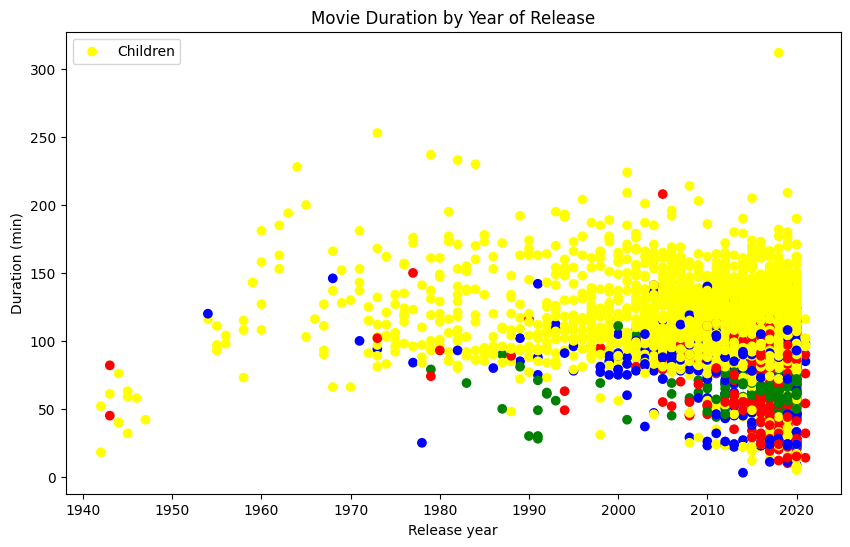

In [19]:


# Make a subset having only Movie Genres. 
netflix_subset =netflix_df[netflix_df['type']=='Movie']


# From the subset only include the following columns 
netflix_movies = netflix_subset[['title', 'country', 'genre', 'release_year', 'duration']]

# Filter out movies that are shorter than 60 minutes. 
short_movies = netflix_movies[netflix_movies['duration'] < 60]



# Define color mapping for genres
genre_colors = {
    "Children": "blue",
    "Documentaries": "red",
    "Stand-Up": "green",
    "Other": "yellow",
}

# Initialize empty list for colors
colors = []

# Iterate through netflix_movies rows
for index, row in netflix_movies.iterrows():
    genre = row["genre"]
    # Assign color based on genre logic
    if genre in genre_colors:
        color = genre_colors[genre]
    else:
        color = genre_colors["Other"]
    colors.append(color)

# Create a figure object
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot with colors
ax.scatter(x=netflix_movies["release_year"], y=netflix_movies["duration"], c=colors)

# Set axis labels and title
ax.set_xlabel("Release year")
ax.set_ylabel("Duration (min)")
ax.set_title("Movie Duration by Year of Release")

# Legend (optional)
legend_labels = list(genre_colors.keys())
ax.legend(legend_labels)

# Show the plot
plt.show()


As we can see, the answer is not as clear as we wanted.  It appears that children's movies have gotten drastically longer since 1940 . 

Next, we can see what the average length is of a children's movie. 


In [20]:
average_length = netflix_movies.query("genre.str.contains('Children')").duration.mean()

print(f"The average length of a children's movie in your data is {average_length:.2f} minutes.")



The average length of a children's movie in your data is 78.09 minutes.


Next, let's see what the average length of the other 3 genres in the data were. 

In [21]:
# Loop through each genre and its query string
for genre, query_string in [("Documentaries", "genre.str.contains('Documentaries')"), ("Stand-Up", "genre == 'Stand-Up'"), ("Other", "genre != 'Children' and genre != 'Documentaries' and genre != 'Stand-Up'")]:
    # Calculate average length based on query
    average_length = netflix_movies.query(query_string).duration.mean()
    
    # Print the result
    print(f"The average length of a {genre} movie is {average_length:.2f} minutes.")


The average length of a Documentaries movie is 81.88 minutes.
The average length of a Stand-Up movie is 66.61 minutes.
The average length of a Other movie is 108.31 minutes.
